In [ ]:
# Importing necessary packages
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import time

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras import backend as K
import tensorflow.keras.backend as K

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

# Path to your dataset
data_path = "/content/drive/MyDrive/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset"

#  Tumor classes
classes = ['no_tumor', 'glioma_tumor', 'meningioma_tumor', 'pituitary_tumor']

#  Target image size
target_size = (128, 128)

# Lists to store images, masks, and labels
images = []
masks = []
labels = []

# Load images and masks
for class_name in classes:
    print(class_name)
    # Build path for image and mask folders
    image_folder = os.path.join(data_path, 'image', str(classes.index(class_name)))
    mask_folder = os.path.join(data_path, 'mask', str(classes.index(class_name)))

    #  Check if the folders exist
    if os.path.exists(image_folder) and os.path.exists(mask_folder):
        #  Loop through each image in the image folder
        for image_name in tqdm(os.listdir(image_folder), desc=f"Loading {class_name}"):
            if image_name.endswith('.jpg') or image_name.endswith('.png'):
                #  Load the image
                image_path = os.path.join(image_folder, image_name)
                image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
                image = cv2.resize(image, target_size)
                image = image / 255.0  # Normalize image

                #  Generate mask name
                mask_name = image_name.replace('.jpg', '_m.jpg').replace('.png', '_m.png')
                mask_path = os.path.join(mask_folder, mask_name)

                # Check if the mask exists
                if os.path.exists(mask_path):
                    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
                    mask = cv2.resize(mask, target_size)
                    mask = mask / 255.0  # Normalize mask

                    #  Append data to lists
                    images.append(image)
                    masks.append(mask)
                    labels.append(classes.index(class_name))
                else:
                    print(f"[WARNING] Missing mask for image: {image_name}")
    else:
        print(f"[ERROR] Missing folder for: {class_name}")

#  Convert lists to NumPy arrays
images = np.array(images).reshape(-1, 128, 128, 1)
masks = np.array(masks).reshape(-1, 128, 128, 1)
labels = np.array(labels)

#  Print dataset size
print(f"\n Total Images: {len(images)}")
print(f" Total Masks: {len(masks)}")
print(f"Total Labels: {len(labels)}")

#  Verify if image-mask-label size matches
assert len(images) == len(masks), "Mismatch between images and masks!"
assert len(images) == len(labels), "Mismatch between images and labels!"


no_tumor


Loading no_tumor: 100%|██████████| 1595/1595 [00:23<00:00, 67.84it/s]


glioma_tumor


Loading glioma_tumor: 100%|██████████| 649/649 [00:09<00:00, 66.95it/s]


meningioma_tumor


Loading meningioma_tumor: 100%|██████████| 999/999 [00:17<00:00, 55.73it/s]


pituitary_tumor


Loading pituitary_tumor: 100%|██████████| 994/994 [00:17<00:00, 57.36it/s]



 Total Images: 4237
 Total Masks: 4237
Total Labels: 4237


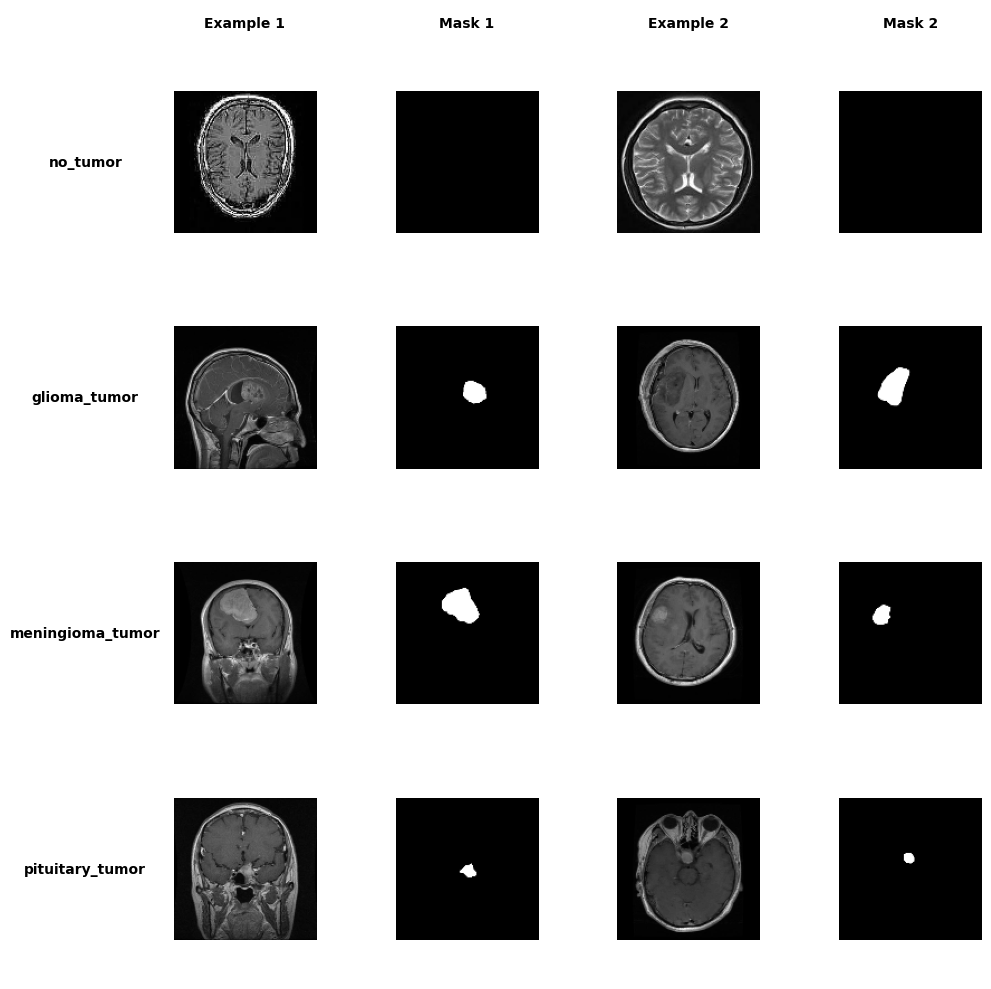

In [ ]:
# Initialize the figure with a grid for 4 classes
fig, axs = plt.subplots(len(classes) + 1, 5, figsize=(10, 10),
                         gridspec_kw={'width_ratios': [0.5, 4, 4, 4 ,4], 'height_ratios': [0.5, 4, 4, 4, 4]})

# Column titles
axs[0, 0].text(0.5, 0.5, "", fontsize=10, ha='center', va='center', fontweight='bold')
axs[0, 0].axis('off')  # Remove axes

axs[0, 1].text(0.5, 0.5, "Example 1", fontsize=10, ha='center', va='center', fontweight='bold')
axs[0, 1].axis('off')  # Remove axes

axs[0, 2].text(0.5, 0.5, "Mask 1", fontsize=10, ha='center', va='center', fontweight='bold')
axs[0, 2].axis('off')  # Remove axes

axs[0, 3].text(0.5, 0.5, "Example 2", fontsize=10, ha='center', va='center', fontweight='bold')
axs[0, 3].axis('off')  # Remove axes

axs[0, 4].text(0.5, 0.5, "Mask 2", fontsize=10, ha='center', va='center', fontweight='bold')
axs[0, 4].axis('off')  # Remove axes

for i, class_name in enumerate(classes):
    # Find an index of an image and mask for each class
    class_index = classes.index(class_name)

    # Retrieve an example image and mask for each class
    example_index1 = np.where(labels == class_index)[0][0]  # Take the first example of each class
    example_index2 = np.where(labels == class_index)[0][2]  # Take the second example
    image1 = images[example_index1]
    mask1 = masks[example_index1]

    image2 = images[example_index2]
    mask2 = masks[example_index2]

    # Display the image
    axs[i + 1, 1].imshow(image1, cmap='gray')
    axs[i + 1, 1].axis('off')  # Remove axes

    # Display the mask
    axs[i + 1, 2].imshow(mask1, cmap='gray')
    axs[i + 1, 2].axis('off')  # Remove axes

    # Display the image
    axs[i + 1, 3].imshow(image2, cmap='gray')
    axs[i + 1, 3].axis('off')  # Remove axes

    # Display the mask
    axs[i + 1, 4].imshow(mask2, cmap='gray')
    axs[i + 1, 4].axis('off')  # Remove axes

    # Center the text in the class column
    axs[i + 1, 0].text(0.5, 0.5, class_name, fontsize=10, ha='center', va='center', fontweight='bold')
    axs[i + 1, 0].axis('off')  # Remove axes

plt.tight_layout()
plt.show()


In [ ]:
# Split the data into training (75%) and validation (25%) sets
images_train, images_val, masks_train, masks_val, labels_train, labels_val = train_test_split(
    images, masks, labels, test_size=0.3, random_state=42, stratify=labels, shuffle=True
)

# Display the dimensions of the sets
print(f"Training set - Images: {images_train.shape}, Masks: {masks_train.shape}, Labels: {labels_train.shape}")
print(f"Validation set - Images: {images_val.shape}, Masks: {masks_val.shape}, Labels: {labels_val.shape}")


Training set - Images: (2965, 128, 128, 1), Masks: (2965, 128, 128, 1), Labels: (2965,)
Validation set - Images: (1272, 128, 128, 1), Masks: (1272, 128, 128, 1), Labels: (1272,)


In [ ]:
# Function to create a generator that applies the same augmentation to images and masks
def train_generator(images, masks, batch_size, seed=42):
    image_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    mask_datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    # Generators for images and masks
    image_generator = image_datagen.flow(images, batch_size=batch_size, seed=seed)
    mask_generator = mask_datagen.flow(masks, batch_size=batch_size, seed=seed)

    while True:
        # Generate a batch of images and masks
        img_batch = next(image_generator)  # Use `next(image_generator)`
        mask_batch = next(mask_generator)  # Use `next(mask_generator)`

        yield img_batch, mask_batch


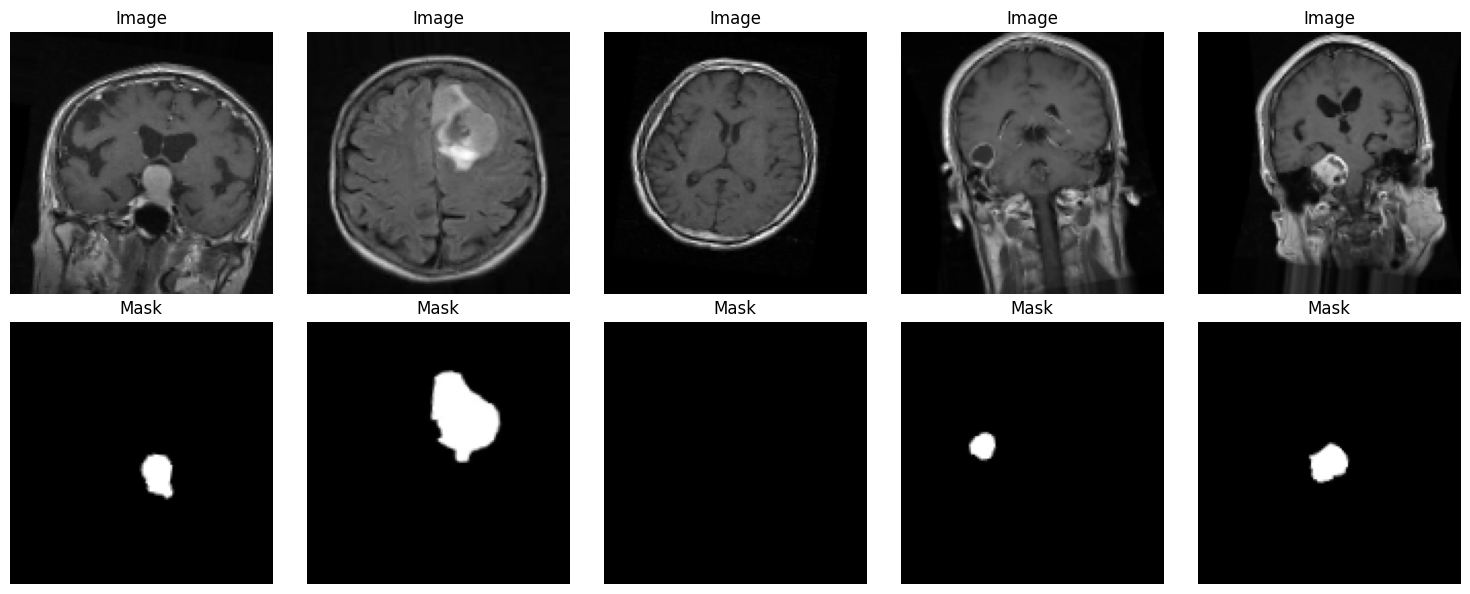

In [ ]:
# Function to display images and their corresponding masks
def plot_images(images, masks, num_images=5):
    plt.figure(figsize=(15, 6))
    for i in range(num_images):
        # Display the image
        plt.subplot(2, num_images, i + 1)
        plt.imshow(images[i].reshape(128, 128), cmap='gray')  # Adjust shape if necessary
        plt.axis('off')
        plt.title('Image')

        # Display the corresponding mask
        plt.subplot(2, num_images, i + 1 + num_images)
        plt.imshow(masks[i].reshape(128, 128), cmap='gray')  # Adjust shape if necessary
        plt.axis('off')
        plt.title('Mask')

    plt.tight_layout()
    plt.show()

# Test the augmentation generator by taking a few images
images_batch, masks_batch = next(train_generator(images_train, masks_train, batch_size=5))

# Display the images and masks
plot_images(images_batch, masks_batch, num_images=5)


In [ ]:
def enhance_tumor(image, mask, intensity=2.2, dim_background=0.9):
    # Convert grayscale to BGR for color highlighting
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Intensify tumor area
    tumor_area = cv2.bitwise_and(image, image, mask=mask)
    tumor_enhanced = np.clip(tumor_area * intensity, 0, 255).astype(np.uint8)

    # Dim the background
    background_mask = cv2.bitwise_not(mask)
    background = cv2.bitwise_and(image, image, mask=background_mask)
    background_dimmed = np.clip(background * dim_background, 0, 255).astype(np.uint8)

    # Combine both
    result = cv2.add(tumor_enhanced, background_dimmed)

    # Draw contour around tumor in red
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(result, contours, -1, (0, 0, 255), thickness=2)  # RED boundary

    return result


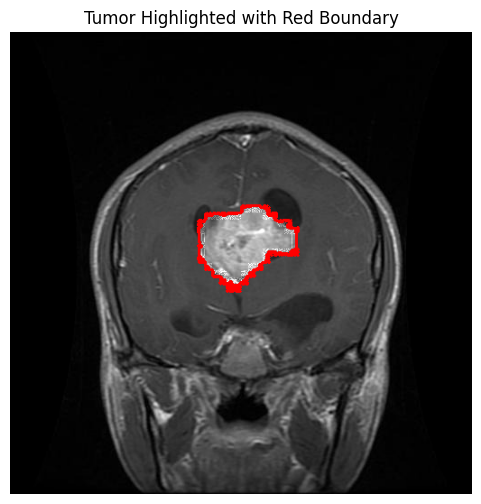

In [ ]:
img = cv2.imread("/content/drive/MyDrive/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/image/1/Tr-glTr_0001.jpg")
mask = cv2.imread('/content/drive/MyDrive/brain-tumor-segmentation-dataset/Brain Tumor Segmentation Dataset/mask/1/Tr-glTr_0001_m.jpg', cv2.IMREAD_GRAYSCALE)
highlighted = enhance_tumor(img, mask, intensity=1.6, dim_background=0.9)

plt.figure(figsize=(6,6))
plt.imshow(cv2.cvtColor(highlighted, cv2.COLOR_BGR2RGB))
plt.title("Tumor Highlighted with Red Boundary")
plt.axis("off")
plt.show()

In [ ]:
# Dice Coefficient
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# Dice Loss (to be used as a loss function)
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

# Intersection over Union (IoU)
def iou(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    total = K.sum(y_true_f) + K.sum(y_pred_f)
    union = total - intersection
    return (intersection + smooth) / (union + smooth)


In [ ]:
# Define the U-Net model
def unet_model(input_shape):
    inputs = layers.Input(input_shape)

    # Contracting Path
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Dropout(0.1)(c1)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Dropout(0.1)(c2)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Dropout(0.2)(c3)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Dropout(0.2)(c4)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Bottleneck
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Dropout(0.3)(c5)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Expanding Path
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Dropout(0.2)(c6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Dropout(0.2)(c7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Dropout(0.1)(c8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Dropout(0.1)(c9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    # Output layer with a single channel for binary segmentation
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    # Create the model
    model = models.Model(inputs=[inputs], outputs=[outputs])

    return model


# Define input shape (height, width, channels)
input_shape = (128, 128, 1)
model = unet_model(input_shape)
model.summary()

# Compile the model
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy', dice_coefficient, iou])


I0000 00:00:1744907306.937361      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 128, 128, 64)   │              0 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 64, 64, 128)    │              0 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ dropout_1[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_2 (Dropout)       │ (None, 32, 32, 256)    │              0 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ dropout_2[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 16, 16, 512)    │              0 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)    

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define callbacks
model_checkpoint = ModelCheckpoint('best_unetmodel.keras',  # Filename to save the best model
                                   monitor='val_dice_coefficient',  # Monitor the validation Dice Coefficient
                                   save_best_only=True,  # Save only the best model
                                   mode='max',  # Look for the maximum value
                                   verbose=1  # Display a message when saving
                                  )

early_stopping = EarlyStopping(monitor='val_dice_coefficient',
                               patience=10,  # Stop after 10 epochs without improvement
                               mode='max',  # Look for the maximum value
                               verbose=1  # Display a message when stopping
                              )

# Use the augmentation generator for training
batch_size = 32
train_gen = train_generator(images_train, masks_train, batch_size=batch_size)

# Train the model using the generator
history = model.fit(
    train_gen,
    steps_per_epoch=len(images_train) // batch_size,
    epochs=50,
    validation_data=(images_val, masks_val),
    callbacks=[model_checkpoint, early_stopping]
)


Epoch 1/50


I0000 00:00:1744907318.394651      84 service.cc:148] XLA service 0x7e19c400c010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744907318.395532      84 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744907319.401039      84 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744907345.658081      84 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9507 - dice_coefficient: 0.0134 - iou: 0.0068 - loss: 0.3859
Epoch 1: val_dice_coefficient improved from -inf to 0.04566, saving model to best_unetmodel.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 73s 394ms/step - accuracy: 0.9510 - dice_coefficient: 0.0134 - iou: 0.0068 - loss: 0.3838 - val_accuracy: 0.9874 - val_dice_coefficient: 0.0457 - val_iou: 0.0234 - val_loss: 0.0553
Epoch 2/50


E0000 00:00:1744907387.171366      82 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744907387.408570      82 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9851 - dice_coefficient: 0.0331 - iou: 0.0169 - loss: 0.0489
Epoch 2: val_dice_coefficient improved from 0.04566 to 0.05450, saving model to best_unetmodel.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 44s 245ms/step - accuracy: 0.9851 - dice_coefficient: 0.0331 - iou: 0.0169 - loss: 0.0488 - val_accuracy: 0.9874 - val_dice_coefficient: 0.0545 - val_iou: 0.0281 - val_loss: 0.0568
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9858 - dice_coefficient: 0.0402 - iou: 0.0206 - loss: 0.0437
Epoch 3: val_dice_coefficient improved from 0.05450 to 0.06187, saving model to best_unetmodel.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 22s 245ms/step - accuracy: 0.9858 - dice_coefficient: 0.0402 - iou: 0.0206 - loss: 0.0437 - val_accuracy: 0.9874 - val_dice_coefficient: 0.0619 - val_iou: 0.0320 - val_loss: 0.0475
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step - accuracy: 0.9851 - dice_coefficient: 0.0447 - iou: 0.0230 - loss: 0.0460
Epoch 4: val

In [ ]:
model.save("models/brain_tumor_classifier.h5")

In [ ]:
train_loss, train_accuracy, train_dice_coef, train_iou_coef = model.evaluate(images_train, masks_train, verbose=1)
print(f'Training Loss: {train_loss:.4f}')
print(f'Training Accuracy: {train_accuracy:.4f}')
print(f'Training Dice Coefficient: {train_dice_coef:.4f}')
print(f'Training IoU Coefficient: {train_iou_coef:.4f}')

92/93 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.9944 - dice_coefficient: 0.8494 - iou: 0.7390 - loss: 0.0052

E0000 00:00:1744908472.445156      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744908472.682558      84 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - accuracy: 0.9944 - dice_coefficient: 0.8494 - iou: 0.7390 - loss: 0.0052
Training Loss: 0.0050
Training Accuracy: 0.9946
Training Dice Coefficient: 0.8506
Training IoU Coefficient: 0.7409


In [ ]:
val_loss, val_accuracy, val_dice_coef, val_iou_coef = model.evaluate(images_val, masks_val, verbose=1)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')
print(f'Validation Dice Coefficient: {val_dice_coef:.4f}')
print(f'Validation IoU Coefficient: {val_iou_coef:.4f}')

40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.9944 - dice_coefficient: 0.8352 - iou: 0.7181 - loss: 0.0062
Validation Loss: 0.0062
Validation Accuracy: 0.9944
Validation Dice Coefficient: 0.8354
Validation IoU Coefficient: 0.7184


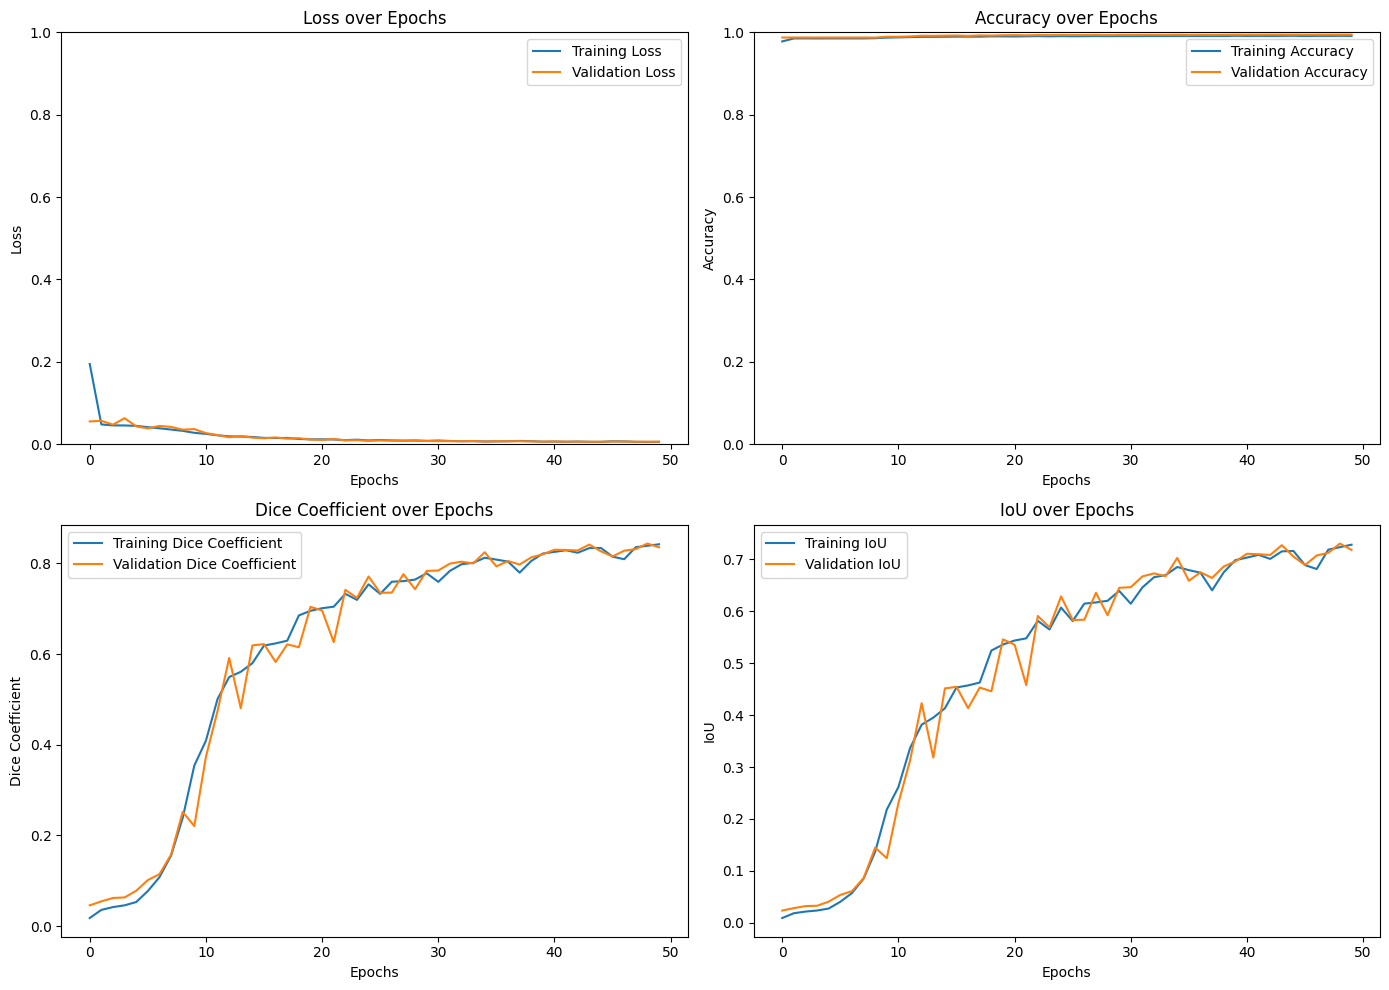

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Plot the Loss curve
axs[0, 0].plot(history.history['loss'], label='Training Loss')
axs[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axs[0, 0].set_title('Loss over Epochs')
axs[0, 0].set_xlabel('Epochs')
axs[0, 0].set_ylabel('Loss')
axs[0, 0].set_ylim(0, 1)
axs[0, 0].legend()

# Plot the Accuracy curve
axs[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axs[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axs[0, 1].set_title('Accuracy over Epochs')
axs[0, 1].set_xlabel('Epochs')
axs[0, 1].set_ylabel('Accuracy')
axs[0, 1].set_ylim(0, 1)
axs[0, 1].legend()

# Plot the Dice Coefficient curve
axs[1, 0].plot(history.history['dice_coefficient'], label='Training Dice Coefficient')
axs[1, 0].plot(history.history['val_dice_coefficient'], label='Validation Dice Coefficient')
axs[1, 0].set_title('Dice Coefficient over Epochs')
axs[1, 0].set_xlabel('Epochs')
axs[1, 0].set_ylabel('Dice Coefficient')
axs[1, 0].legend()

# Plot the IoU curve
axs[1, 1].plot(history.history['iou'], label='Training IoU')
axs[1, 1].plot(history.history['val_iou'], label='Validation IoU')
axs[1, 1].set_title('IoU over Epochs')
axs[1, 1].set_xlabel('Epochs')
axs[1, 1].set_ylabel('IoU')
axs[1, 1].legend()

# Adjust spacing between subplots
plt.tight_layout()
plt.show()


In [ ]:
predictions = model.predict(images_val) # Replace images_test with your test set
predictions = (predictions > 0.5).astype(np.uint8)

40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 79ms/step


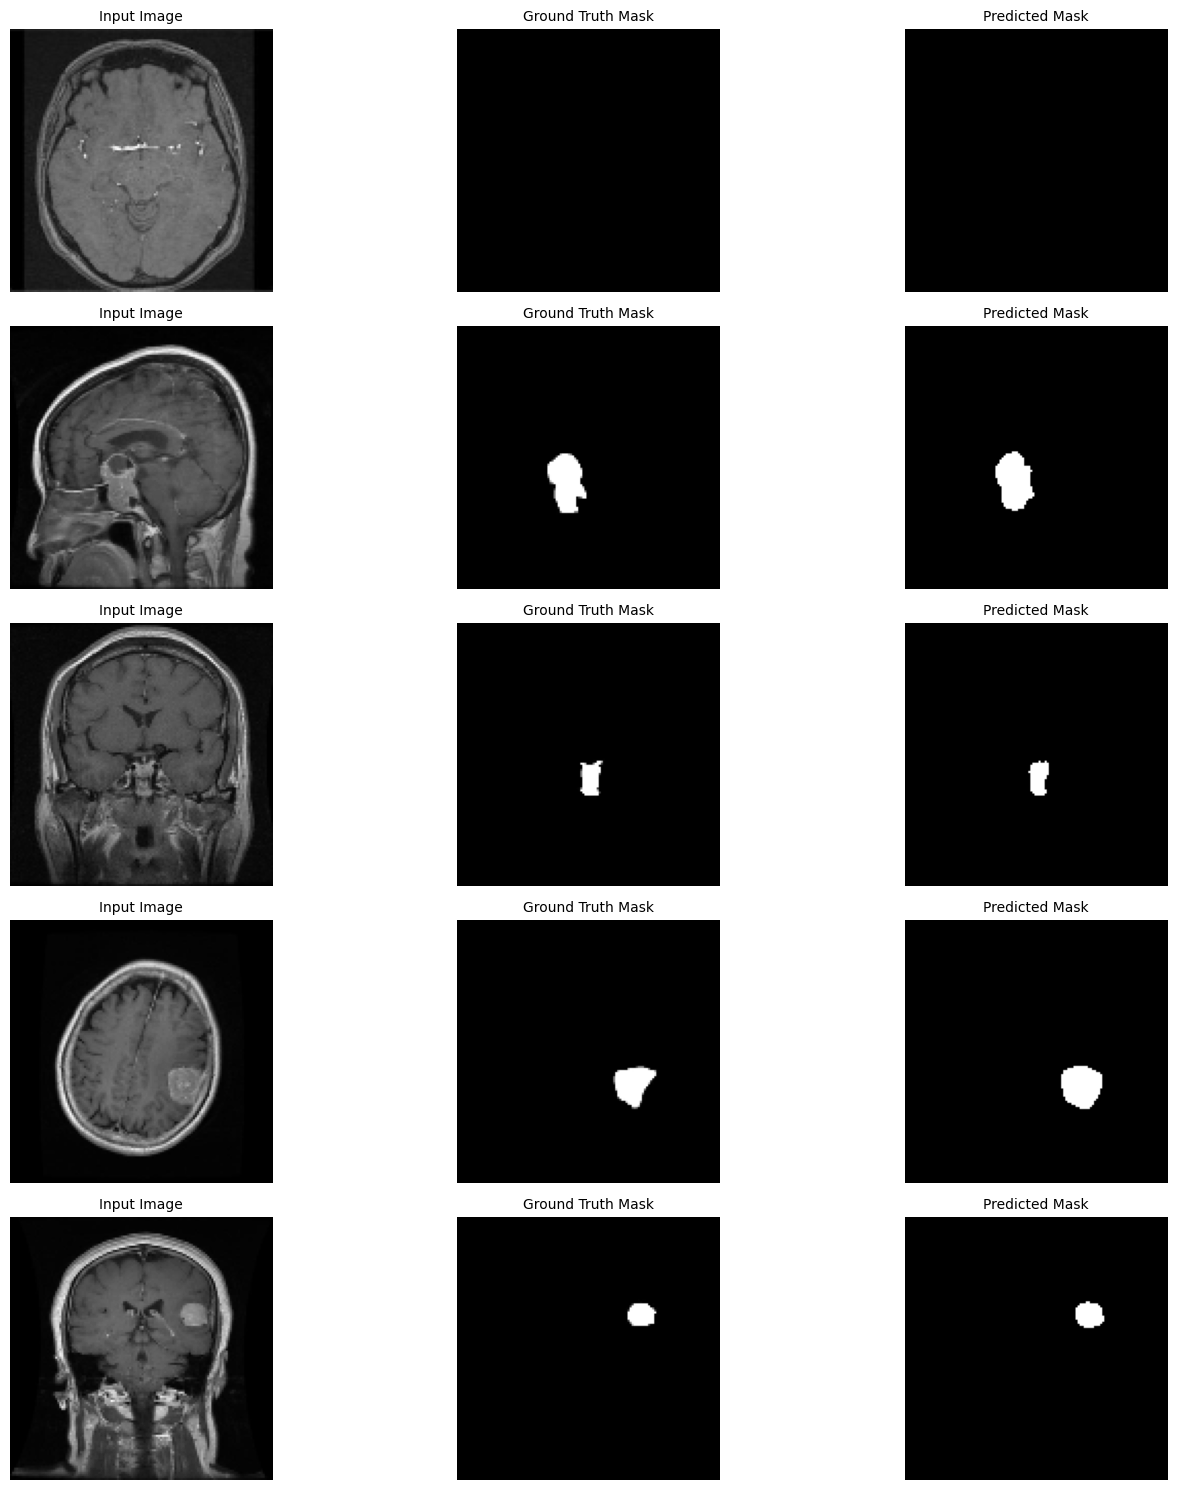

In [ ]:
# Visualize some results
n = 5  # Number of examples to display
plt.figure(figsize=(15, 15))

for i in range(n):
    # Input image
    plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(images_val[i+1].reshape(128, 128), cmap='gray')
    plt.title('Input Image', fontsize=10)
    plt.axis('off')

    # Ground truth mask
    plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(masks_val[i+1].reshape(128, 128), cmap='gray')
    plt.title('Ground Truth Mask', fontsize=10)
    plt.axis('off')

    # Predicted mask
    plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(predictions[i+1].reshape(128, 128), cmap='gray')
    plt.title('Predicted Mask', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()
